In [1]:
import pandas as pd
import matplotlib.pyplot as plt

orders_delivered = pd.read_csv('../data/orders_delivered_clean.csv')
orders_delivered.shape

(95082, 13)

In [2]:
total_mean = orders_delivered['total_delivery_time'].mean()

bottleneck_summary = pd.DataFrame({
    'stage': ['payment_approval', 'seller_processing', 'carrier_delivery'],
    'avg_hours': [
        orders_delivered['payment_approval_time'].mean(),
        orders_delivered['seller_processing_time'].mean(),
        orders_delivered['carrier_delivery_time'].mean()
    ],
    'lead_time_ratio': [
        orders_delivered['payment_approval_time'].mean() / total_mean,
        orders_delivered['seller_processing_time'].mean() / total_mean,
        orders_delivered['carrier_delivery_time'].mean() / total_mean
    ]
})

print(bottleneck_summary)

               stage   avg_hours  lead_time_ratio
0   payment_approval    9.650495         0.031868
1  seller_processing   68.441959         0.226007
2   carrier_delivery  224.738670         0.742125


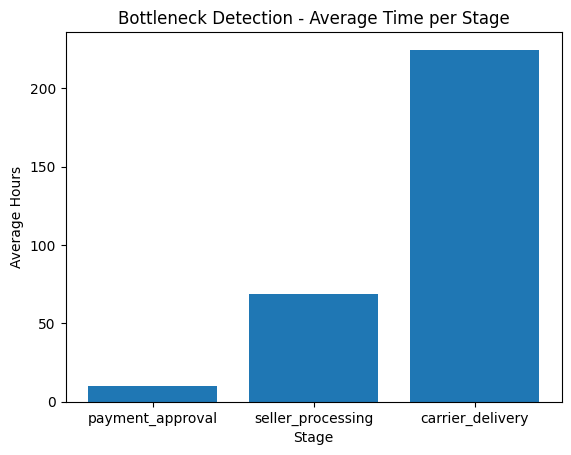

In [4]:
plt.bar(bottleneck_summary['stage'], bottleneck_summary['avg_hours'])
plt.xlabel('Stage')
plt.ylabel('Average Hours')
plt.title('Bottleneck Detection - Average Time per Stage')
plt.show()

In [5]:
delayed = orders_delivered[orders_delivered['delivery_delay'] > 0]
normal = orders_delivered[orders_delivered['delivery_delay'] <= 0]

cols = ['payment_approval_time', 'seller_processing_time', 'carrier_delivery_time']

print("=== 지연 주문 ===")
print(delayed[cols].mean())
print("\n=== 정상 주문 ===")
print(normal[cols].mean())

=== 지연 주문 ===
payment_approval_time      12.045650
seller_processing_time    128.380266
carrier_delivery_time     616.337537
dtype: float64

=== 정상 주문 ===
payment_approval_time       9.436690
seller_processing_time     63.091526
carrier_delivery_time     189.782337
dtype: float64


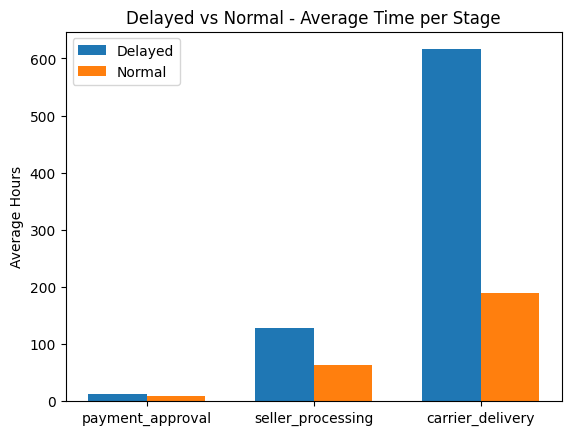

In [ ]:
comparison = pd.DataFrame({
    'stage': cols,
    'delayed': delayed[cols].mean().values,
    'normal': normal[cols].mean().values
})

x = range(len(cols))
width = 0.35

plt.bar([i - width/2 for i in x], comparison['delayed'], width, label='Delayed')
plt.bar([i + width/2 for i in x], comparison['normal'], width, label='Normal')
plt.xticks(x, ['payment_approval', 'seller_processing', 'carrier_delivery'])
plt.ylabel('Average Hours')
plt.title('Delayed vs Normal - Average Time per Stage')
plt.legend()
plt.show()

In [1]:
delay_rate = len(delayed) / len(orders_delivered) * 100
print(f"지연율: {delay_rate:.2f}%")

NameError: name 'delayed' is not defined